In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

RMSE: 0.15599302596961692


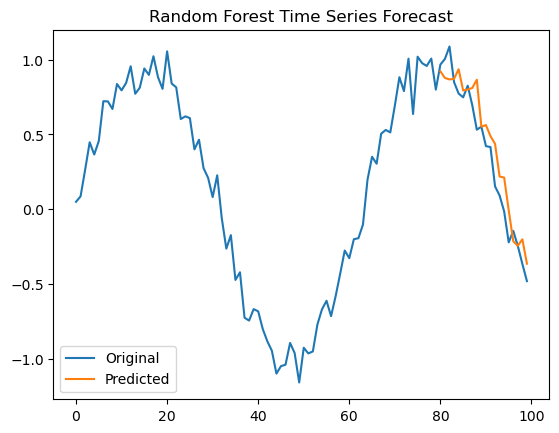

In [2]:
# 1. Create sample time series data
np.random.seed(42)
time = np.arange(100)
series = np.sin(0.1 * time) + np.random.normal(scale=0.1, size=100)

# 2. Convert to supervised learning (create lag features)
def create_lag_features(data, lag=3):
    df = pd.DataFrame(data, columns=['y'])
    for i in range(1, lag+1):
        df[f'lag_{i}'] = df['y'].shift(i)
    df.dropna(inplace=True)
    return df

lag = 3
df = create_lag_features(series, lag)

# 3. Split into train and test
train_size = int(len(df) * 0.8)
train, test = df[:train_size], df[train_size:]

X_train, y_train = train.drop('y', axis=1), train['y']
X_test, y_test = test.drop('y', axis=1), test['y']

# 4. Train Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Predict
y_pred = model.predict(X_test)

# 6. Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

# 7. Plot results
plt.figure()
plt.plot(range(len(series)), series, label='Original')
plt.plot(range(train_size+lag, len(series)), y_pred, label='Predicted')
plt.legend()
plt.title("Random Forest Time Series Forecast")
plt.show()